1.- Se crea un contrato de compra donde se quiere que la acción sea estable. La persona con la que estás haciendo el contrato accede a comprar el 50% de las acciones de tu empresa si la volatilidad móvil con n=20 (anualizada) no excede el 20%. El archivo ex1_01 contiene dos rutas. ¿En cuál de las dos situaciones se activa el contrato?



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_excel('ex1_01.xlsx')
df.head()


,Día,Ruta A,Ruta B
0,0,100.0,100.0
1,1,101.2,101.3
2,2,100.4,99.9
3,3,102.0,101.8
4,4,101.5,100.6


In [3]:
df['Rendimiento_A']=np.log(df['Ruta A']/df['Ruta A'].shift(1))

df['Rendimiento_B']=np.log(df['Ruta B']/df['Ruta B'].shift(1))

In [4]:
print(df[['Día','Ruta A','Rendimiento_A']])
print(df[['Día','Ruta B','Rendimiento_B']])

    Día  Ruta A  Rendimiento_A
0     0   100.0            NaN
1     1   101.2       0.011929
2     2   100.4      -0.007937
3     3   102.0       0.015811
4     4   101.5      -0.004914
5     5   103.1       0.015641
6     6   102.4      -0.006813
7     7   104.2       0.017425
8     8   103.6      -0.005775
9     9   105.0       0.013423
10   10   104.1      -0.008608
11   11   105.7       0.015253
12   12   104.8      -0.008551
13   13   106.3       0.014212
14   14   105.5      -0.007554
15   15   107.1       0.015052
16   16   106.4      -0.006557
17   17   108.0       0.014926
18   18   107.2      -0.007435
19   19   108.8       0.014815
20   20   107.9      -0.008306
21   21   109.4       0.013806
22   22   108.6      -0.007339
23   23   110.1       0.013718
24   24   109.2      -0.008208
25   25   110.8       0.014546
26   26   109.9      -0.008156
27   27   111.5       0.014454
28   28   110.6      -0.008105
29   29   112.1       0.013471
30   30   111.3      -0.007162
31   31 

In [5]:
rendimiento_A=df['Rendimiento_A'].dropna()
rendimiento_B=df['Rendimiento_B'].dropna()


In [6]:
mu=np.mean(rendimiento_A)
mu=np.mean(rendimiento_B)
sigma=np.std(rendimiento_A,ddof=1)
sigma=np.std(rendimiento_B,ddof=1)


In [11]:
#Lista
n=20
vol_1=[]
vol_2=[]
for i in range(len(rendimiento_A)-n+1):
    valores_1=rendimiento_A.iloc[i:i+n]
    valores_2=rendimiento_B.iloc[i:i+n]
    desviacion_1=np.std(valores_1,ddof=1)
    desviacion_2=np.std(valores_2,ddof=1)
vol_1.append(desviacion_1)
vol_2.append(desviacion_2)

vol_1=np.array(vol_1)
vol_2=np.array(vol_2)

vol_1_annual=vol_1*np.sqrt(252)
vol_2_annual=vol_2*np.sqrt(252)
    
limite=0.20
print("Máxima volatilidad anual de A:", np.max(vol_1_annual))
print("Máxima volatilidad anual de B:", np.max(vol_2_annual))



Máxima volatilidad anual de A: 0.1491818895581778
Máxima volatilidad anual de B: 0.292968932824413


Se activa el contrato en la ruta A ya que en la B se excede el limite de .20 

2.- Utilizando S0=100, r=0.05, sigma=0.20, T=1, n=252, y un GBM, considera los siguientes supuestos:

A partir del día 30 sabes que el banco central aumentará las tasas de interés al 8%
Sabes que a partir del día 50, después de una junta de accionistas, la volatilidad aumentará a 40% por 20 días; luego de eso, regresará a la normalidad.
Históricamente, las veces que se ha hecho un anuncio importante sobre el portafolio de la empresa para nuevos productos de venta, se producen reacciones fuertemente positivas e inmediatas en el precio de la acción durante 1 semana; se regresa a la normalidad después de esa semana. La presentación está calendarizada para el día 120.
Incorpora todo esta información en una simulación Monte Carlo con M=10000. Tip: simula día tras día.

Entrega:

Código modificado para agregar esta información
Markdown con justificación para cada modificación realizada
Una gráfica con al menos 20 trayectorias simuladas con un marcador de dónde son los cambios abruptos.


Text(0, 0.5, 'Precio')

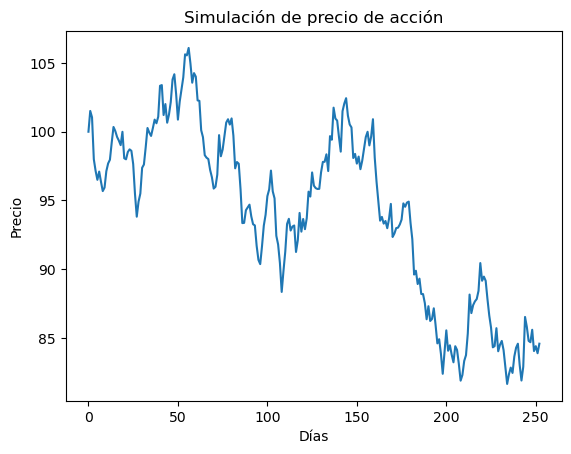

In [16]:
S0=100
r=0.05
sigma=0.20
T=1
n=252
M=10000
dt=T/n
#precio inicial
precios=[S0]
#simular precio paso a paso
for i in range(n):
    z=np.random.normal(0,1)
    s_nuevo=precios[-1]*np.exp((r-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*z)
    precios.append(s_nuevo)
#grafica
plt.plot(precios)
plt.title('Simulación de precio de acción')
plt.xlabel('Días')
plt.ylabel('Precio')





